In [1]:
%matplotlib notebook

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.stats import binned_statistic, gaussian_kde
from scipy.ndimage import gaussian_filter1d
import sys
sys.path.append("../python/")
from _corner import corner
import matplotlib.pyplot as plt

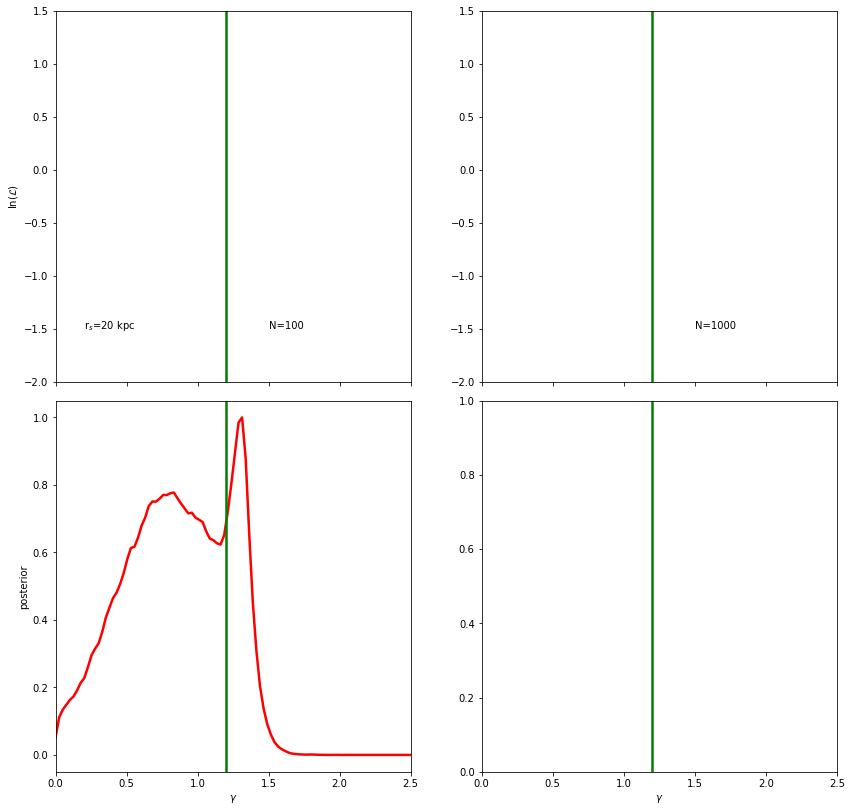

In [16]:
nBDs1 = 100; nBDs2 = 1000
sigma = 0.2
f     = 1.; gamma = 1.2; rs = 10.


fig, axes = plt.subplots(2, 2, figsize=(14, 14), sharex=True)
axes[0, 0].set_ylim(-2, 1.5); axes[0, 1].set_ylim(-2, 1.5)
axes[0, 0].set_xlim(0., 2.5); axes[0, 1].set_xlim(0., 2.5)

xvals = axes[0, 0].get_xlim()
xvals = np.linspace(xvals[0], xvals[1], 100)
     
    
axes[1, 0].set_xlabel(r"$\gamma$"); axes[1, 1].set_xlabel(r"$\gamma$")

smooth=0.8

ls = [ "-", ":", "-.", "--", (0, (1, 10)), (0, (1, 1)), (0, (3, 10, 1, 10))]
j  = 0


rank = 8
_file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                            %(nBDs1, rank)), "rb") 
samples  = pickle.load(_file)

kde   = gaussian_kde(samples[:, 1])
axes[1, 0].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)#, ls=ls[j]) 

axes[0, 0].set_ylabel(r"ln($\mathcal{L}$)"); axes[1, 0].set_ylabel("posterior")
axes[0, 0].text(1.5, -1.5, "N=100"); axes[0, 1].text(1.5, -1.5, "N=1000")
axes[0, 0].text(0.2, -1.5, "r$_s$=20 kpc")
    
axes[0, 0].axvline(gamma, color="green", lw=2.5); axes[0, 1].axvline(gamma, color="green", lw=2.5)
axes[1, 0].axvline(gamma, color="green", lw=2.5); axes[1, 1].axvline(gamma, color="green", lw=2.5)
fig.subplots_adjust(hspace=0.05)

Text(0.5, 0, '$\\gamma$')

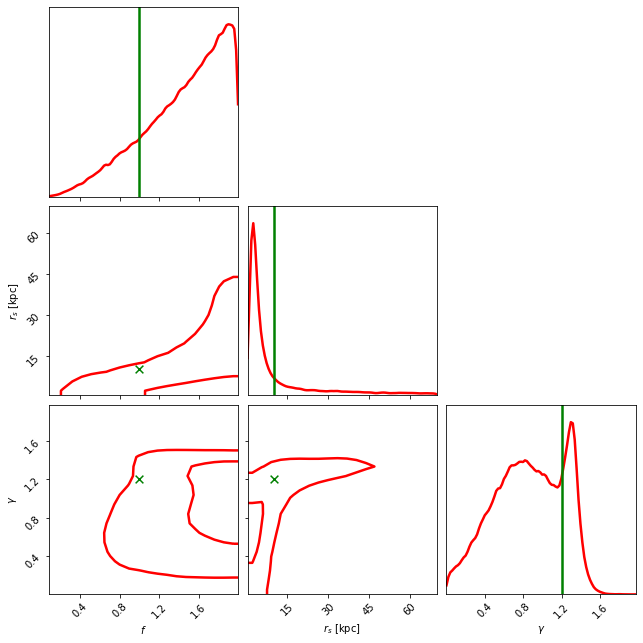

In [15]:
nBDs = 100 ; sigma = 0.2
f = 1.; gamma = 1.2; rs = 10.

rank = 8
_file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                            %(nBDs, rank)), "rb") 
samples  = pickle.load(_file)

smooth=1.
fig, axes = corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

In [17]:
import numpy as np

path = "/home/mariacst/exoplanets/debug/multinest/out/v7/"
i=105

#data = np.genfromtxt(filepath + "out/T650_multinest_N100_gamma1.2_rs10.0_v8phys_live.points", unpack=True)
data = np.genfromtxt(path + "%i/T650_multinest_N100_gamma1.2_rs10.0_v%ipost_equal_weights.dat"%(i, i), 
                     unpack=True)
print(data.shape)

(4, 38645)


In [11]:
for j in range(15):
    i=j+101
    data = np.genfromtxt(path + "out/%i/T650_multinest_N100_gamma1.2_rs10.0_v%ipost_equal_weights.dat"%(i, i), 
                     unpack=True)
    print(i, data[0:3].T.shape)

101 (28312, 3)
102 (35147, 3)
103 (38285, 3)
104 (37636, 3)
105 (26507, 3)
106 (36329, 3)
107 (33561, 3)
108 (37597, 3)
109 (38181, 3)
110 (34411, 3)
111 (28285, 3)
112 (27040, 3)
113 (35449, 3)
114 (35782, 3)
115 (35721, 3)


In [4]:
data[0:3].T.shape

(28285, 3)

In [9]:
np.max(data[3])-np.min(data[3])

11.872713340685436

In [7]:
np.max(data[3])-np.min(data[3])

8.755235445916014

In [8]:
counts, bins = np.histogramdd(data[0:3].T, bins=10)

maxval = np.amax(counts)
pos = np.where(counts==maxval)

print(maxval, np.sqrt(maxval), maxval - np.sqrt(maxval))#, pos)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.)
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)


counts, bins = np.histogramdd(data[0:3].T, bins=3, range=((bins[0][pos[0]][0], bins[0][pos[0]][0]+1), 
                                                           (bins[1][pos[1]][0], bins[1][pos[1]][0]+1), 
                                                           (bins[2][pos[2]][0], bins[2][pos[2]][0]+1)))

maxval = np.amax(counts)
pos = np.where(counts==maxval)
print(maxval, np.sqrt(maxval), maxval - np.sqrt(maxval))#, pos)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.)
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

counts[pos] = -1

maxval = np.amax(counts)
pos = np.where(counts==maxval)
print(maxval)

442.0 21.02379604162864 420.97620395837134
[1.90138193]
[1.17031278]
[17.68608721]
33.0 5.744562646538029 27.25543735346197
[1.96948325]
[1.23155389]
[14.36588677]
30.0


In [31]:
print(bins)
print(counts)

[array([1.80343218, 1.90343218, 2.00343218, 2.10343218, 2.20343218,
       2.30343218, 2.40343218, 2.50343218, 2.60343218, 2.70343218,
       2.80343218]), array([1.08895848, 1.18895848, 1.28895848, 1.38895848, 1.48895848,
       1.58895848, 1.68895848, 1.78895848, 1.88895848, 1.98895848,
       2.08895848]), array([14.25450534, 14.35450534, 14.45450534, 14.55450534, 14.65450534,
       14.75450534, 14.85450534, 14.95450534, 15.05450534, 15.15450534,
       15.25450534])]
[[[3. 6. 2. 8. 4. 2. 4. 2. 1. 1.]
  [0. 0. 0. 2. 0. 0. 0. 0. 3. 1.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]

 [[1. 4. 1. 8. 2. 2. 9. 0. 1. 7.]
  [0. 0. 0. 0. 0. 0. 0. 1. 1. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  [0. 0. 0.

In [53]:
counts, bins = np.histogramdd(data[0:3].T, bins=20)

maxval = np.amax(counts)
pos = np.where(counts==maxval)

print(maxval, pos)

print((bins[0][pos[0]]+bins[0][pos[0]+1])/2.)
print((bins[1][pos[1]]+bins[1][pos[1]+1])/2.)
print((bins[2][pos[2]]+bins[2][pos[2]+1])/2.)

129.0 (array([19]), array([11]), array([4]))
[1.95182432]
[1.16935629]
[16.06018913]


In [39]:
counts[pos]

array([17.])

<IPython.core.display.Javascript object>


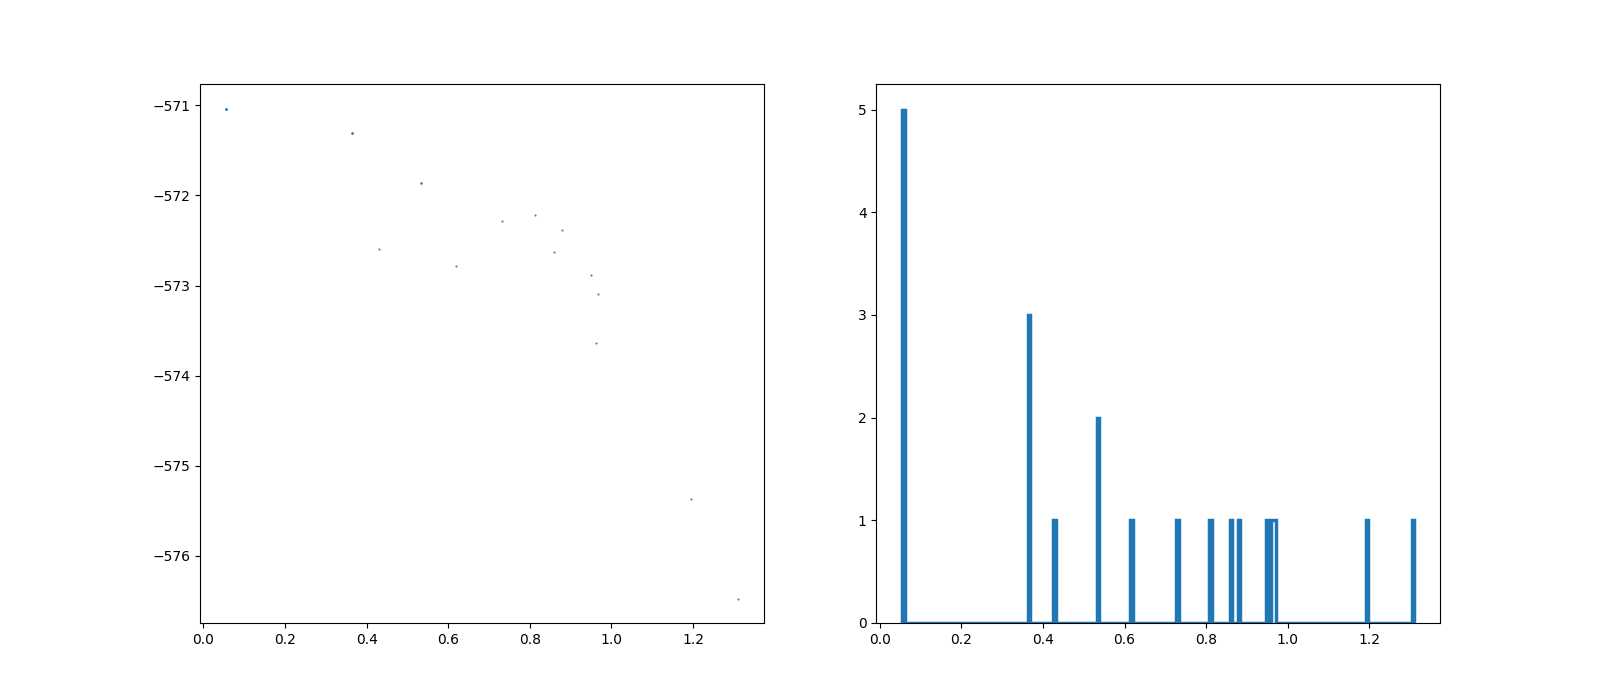

In [39]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

ax[0].scatter(data[1], data[3], s=1, marker="."); ax[1].hist(data[1], bins=200, histtype="step", lw=2.5);

In [13]:
data.shape

(4, 314)

In [11]:
counts, bins = np.histogramdd(np.array((data[1], data[2], data[3])).T , bins=10) 
samples = np.array((data[1], data[2], data[3])).T

samples.shape

(314, 3)

In [10]:
hist = np.copy(samples)
print(hist.shape)

for i in range(len(bins[0])-1):
    for j in range(len(bins[1])-1):
        for k in range(len(bins[2])-1):
            pos = np.where((samples[:, 0] > bins[0][i]) & (samples[:, 0] < bins[0][i+1]) & 
                   (samples[:, 1] > bins[1][j]) & (samples[:, 0] < bins[0][j+1]) &
                   (samples[:, 2] > bins[2][k]) & (samples[:, 0] < bins[0][k+1]))
           # print(counts[i])
            hist[pos] = counts[i, j, k]
            print(hist.shape)

(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(314, 3)
(

In [9]:
hist.T.shape

(3, 314)

<IPython.core.display.Javascript object>


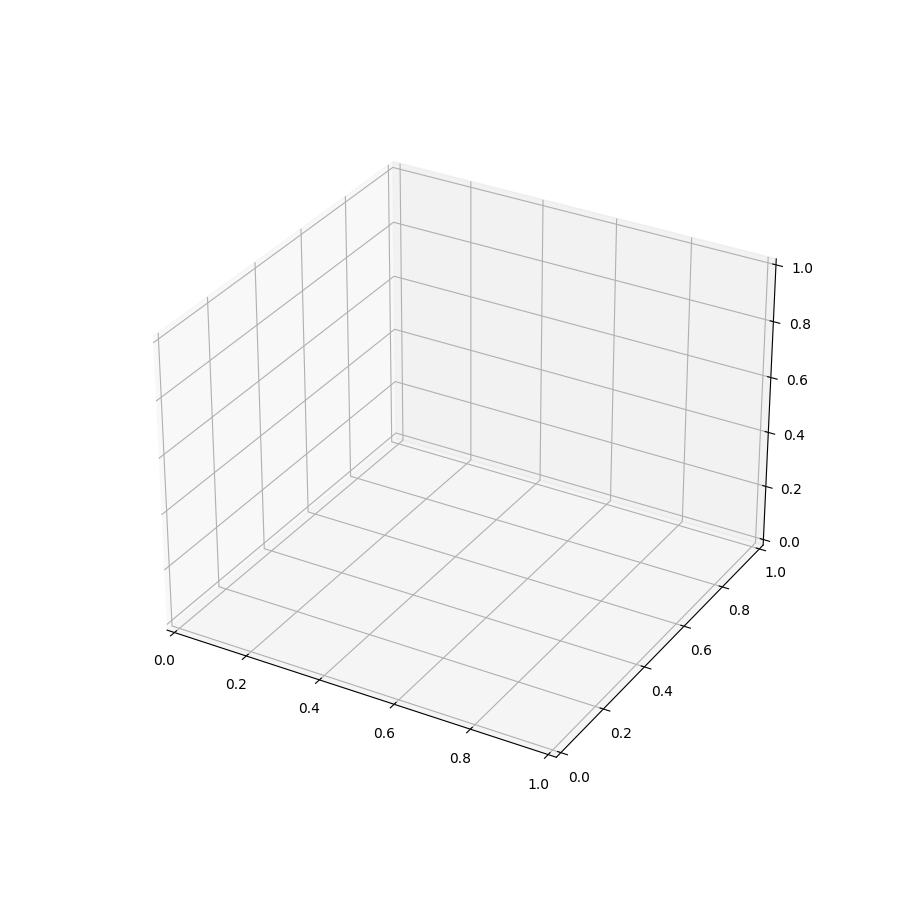

ValueError: 'c' argument has 942 elements, which is inconsistent with 'x' and 'y' with size 314.

In [8]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9, 9))

ax = fig.add_subplot(111, projection='3d')

#plot_ = ax.scatter3D(data[1], data[2], data[0], s=0.1)
ax.scatter(data[1], data[2], data[0],  c=hist.T, cmap='viridis', linewidth=0.5, s=0.5)
ax.scatter(0.134733509563189058E+01, 0.313440322561544633E+02, 0.152227412837361409E+01, color="orange", s=20)

plt.show()

<IPython.core.display.Javascript object>


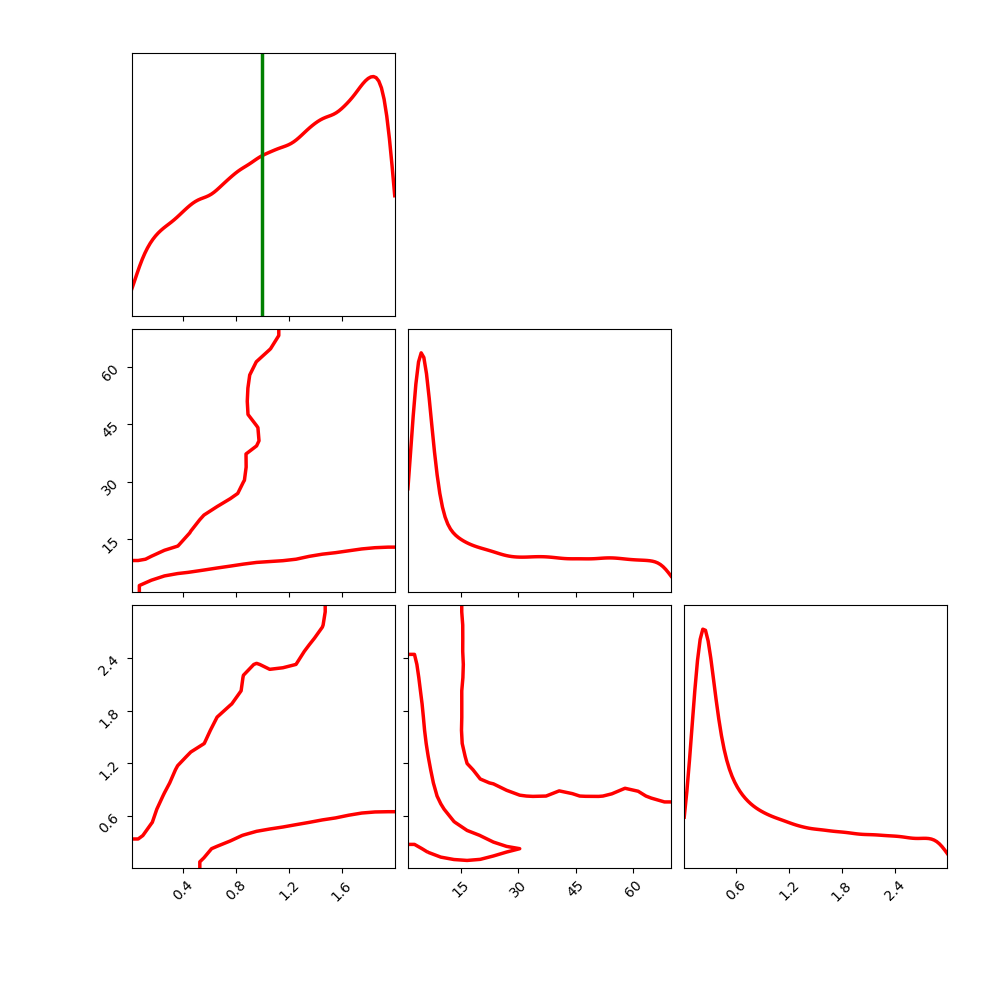

NameError: name 'rs' is not defined

In [6]:
smooth=1.
fig, axes = corner(np.array([data[0], data[2], data[1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([data[0], data[2], data[1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

<IPython.core.display.Javascript object>


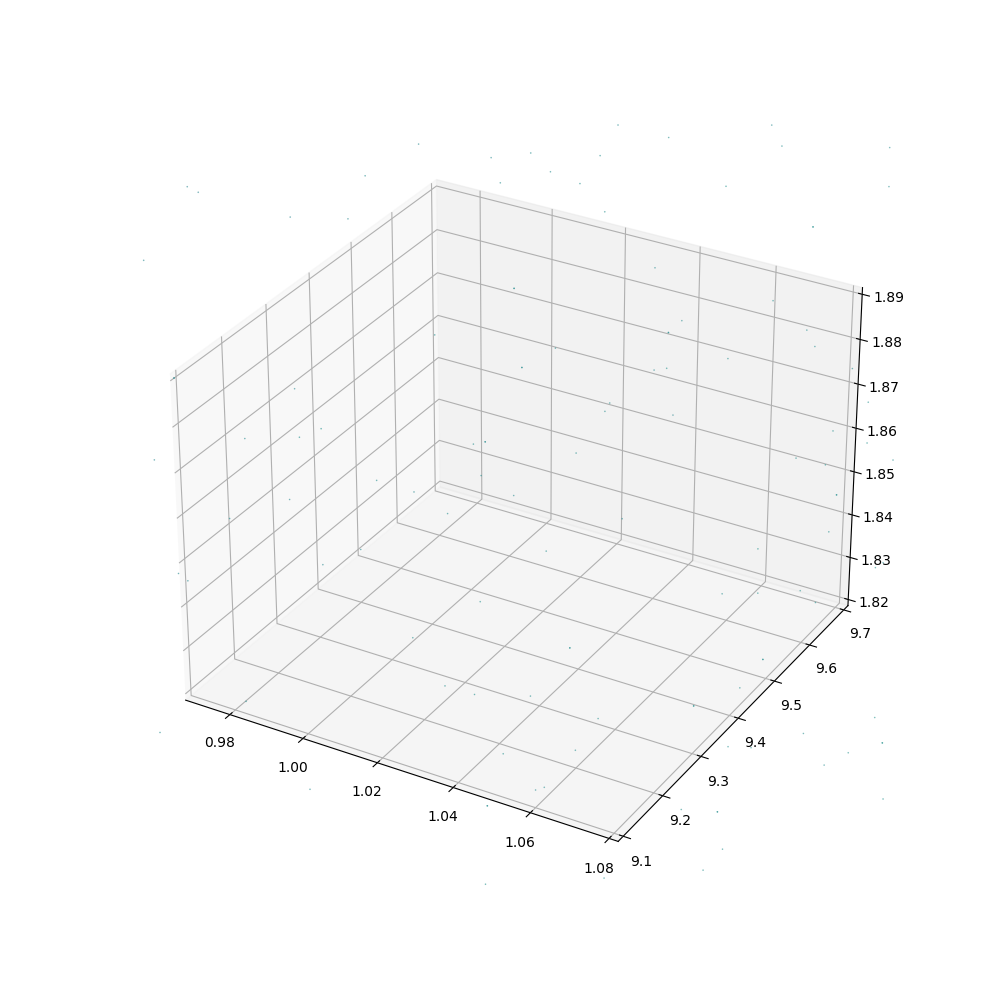

In [6]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

ax.scatter(data[1], data[2], data[0],  c=data[1], cmap='viridis', linewidth=0.5, s=0.5)

ax.set_xlim(0.97, 1.08); ax.set_ylim(9.1, 9.7); ax.set_zlim(1.82, 1.89)

plt.show()

In [9]:
pos = np.where((data[1]>0.97) & (data[1]<1.08) & (data[2]>9.1) & (data[2]<9.7) &
               (data[0]>1.82) & (data[0]<1.89))

len(pos[0])

16

In [2]:
!ls "/home/mariacst/exoplanets/running/gNFW/baseline_NL/out/1/"

baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1.txt
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1IS.iterinfo
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1IS.points
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1IS.ptprob
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1ev.dat
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1live.points
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1phys_live.points
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1post_equal_weights.dat
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1resume.dat
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1stats.dat
baseline_NL_gNFW_N100_gamma0.5_rs5.0_v1summary.txt
baseline_NL_gNFW_N100_sigma0.1_gamma1.5_rs5.0_v1post_equal_weights.dat
baseline_NL_gNFW_N100_sigma0.1_gamma1.5_rs5.0_v1summary.txt


In [ ]:
import numpy as np

filepath = "/home/mariacst/exoplanets/debug/multinest/"

data = np.genfromtxt(filepath + "out/T650_multinest_N100_gamma1.2_rs10.0_v8post_equal_weights.dat", unpack=True)

(4, 25541) (25541,)


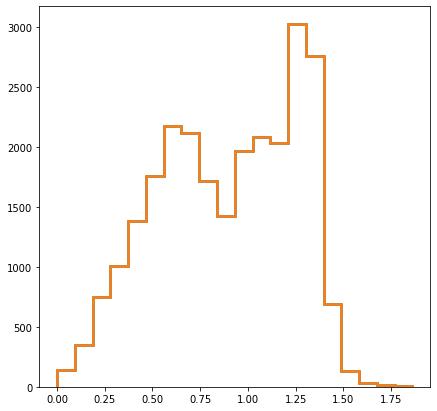

In [19]:
print(data.shape, data[0].shape)

fig, ax = plt.subplots(1, 1, figsize=(7, 7))

ax.hist(data[1], bins=20, histtype="step", lw=2.5);
#ax.hist(samples[:, 1], bins=20, histtype="step", lw=2.5);

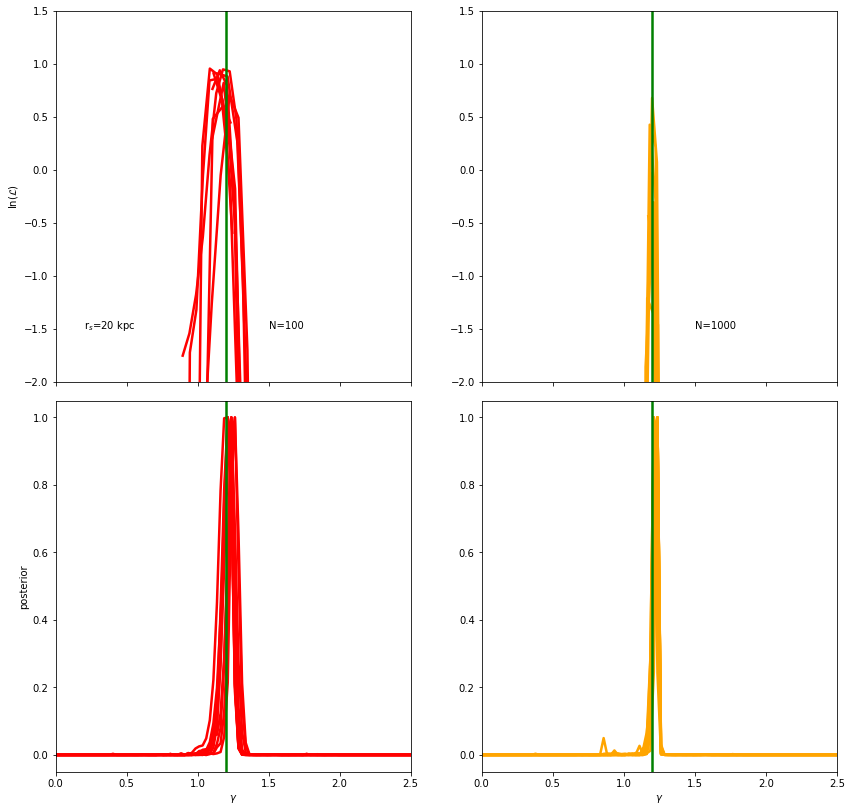

In [17]:
nBDs1 = 100; nBDs2 = 1000
sigma = 0.2
f     = 1.; gamma = 1.2; rs = 10.


fig, axes = plt.subplots(2, 2, figsize=(14, 14), sharex=True)
axes[0, 0].set_ylim(-2, 1.5); axes[0, 1].set_ylim(-2, 1.5)
axes[0, 0].set_xlim(0., 2.5); axes[0, 1].set_xlim(0., 2.5)

xvals = axes[0, 0].get_xlim()
xvals = np.linspace(xvals[0], xvals[1], 100)
     
    
axes[1, 0].set_xlabel(r"$\gamma$"); axes[1, 1].set_xlabel(r"$\gamma$")

smooth=0.8

ls = [ "-", ":", "-.", "--", (0, (1, 10)), (0, (1, 1)), (0, (3, 10, 1, 10))]
j  = 0

for i in range(10):
    rank = i + 3
    filepath = ("/home/mariacst/exoplanets/running/Tcut_non_linear/onlySigmaT/results/sigma0.01/")
    _file    = open(filepath + ("like_Tcut_onlySigmaT_N%i_sigma0.01_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                                %(nBDs1, rank)), "rb") 
    like     = pickle.load(_file)
    _file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_sigma0.01_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                                %(nBDs1, rank)), "rb") 
    samples  = pickle.load(_file)
    bin_n=20
    x = binned_statistic(samples[:, 1], like, 'max', bins=bin_n)[1] 
    y = binned_statistic(samples[:, 1], like, 'max', bins=bin_n+1)[0]
    y = y - np.max(y[~np.isnan(y)]) + 1
    axes[0, 0].plot(x, gaussian_filter1d(y, sigma=smooth), color="r", lw=2.5)#, ls=ls[j])

    kde   = gaussian_kde(samples[:, 1])
    axes[1, 0].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="r", lw=2.5)#, ls=ls[j]) 
    
    _file    = open(filepath + ("like_Tcut_onlySigmaT_N%i_sigma0.01_gamma1.2rs10.0_nwalkers150_steps6000_v%i" 
                                %(nBDs2, rank)), "rb") 
    like     = pickle.load(_file)
    _file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_sigma0.01_gamma1.2rs10.0_nwalkers150_steps6000_v%i" 
                                %(nBDs2, rank)), "rb") 
    samples  = pickle.load(_file)
    bin_n=20
    x = binned_statistic(samples[:, 1], like, 'max', bins=bin_n)[1] 
    y = binned_statistic(samples[:, 1], like, 'max', bins=bin_n+1)[0]
    y = y - np.max(y[~np.isnan(y)]) + 1
    axes[0, 1].plot(x, gaussian_filter1d(y, sigma=smooth), color="orange", lw=2.5)#, ls=ls[j])
    
    kde   = gaussian_kde(samples[:, 1])
    axes[1, 1].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="orange", lw=2.5)#, ls=ls[j]) 
    
    j+=1

axes[0, 0].set_ylabel(r"ln($\mathcal{L}$)"); axes[1, 0].set_ylabel("posterior")
axes[0, 0].text(1.5, -1.5, "N=100"); axes[0, 1].text(1.5, -1.5, "N=1000")
axes[0, 0].text(0.2, -1.5, "r$_s$=20 kpc")
    
axes[0, 0].axvline(gamma, color="green", lw=2.5); axes[0, 1].axvline(gamma, color="green", lw=2.5)
axes[1, 0].axvline(gamma, color="green", lw=2.5); axes[1, 1].axvline(gamma, color="green", lw=2.5)
fig.subplots_adjust(hspace=0.05)

#fig.savefig("like_post_nonlinear_fixedT10v100Tcut_sigmaM0_sigma0.2_gamma1.2_rs10.pdf", bbox_inches="tight")

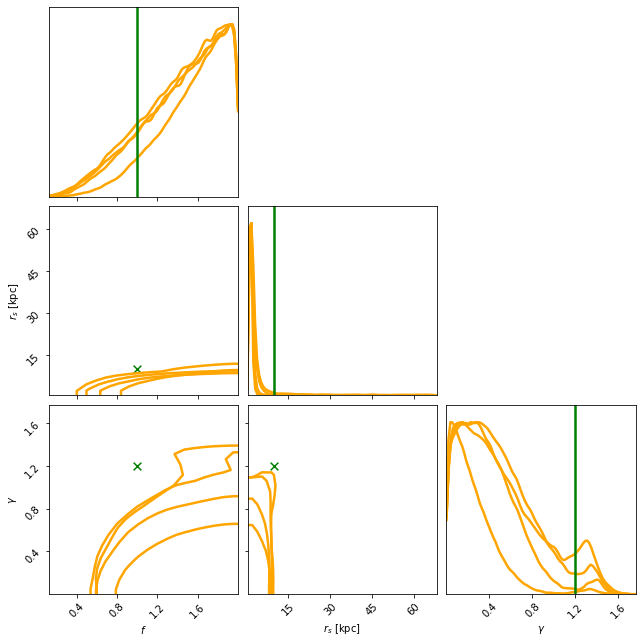

In [24]:
nBDs = 100 ; sigma = 0.2
f = 1.; gamma = 1.2; rs = 10.

filepath = ("/home/mariacst/exoplanets/running/Tcut_non_linear/results/posterior/")
_file    = open(filepath + ("posterior_fixedT10v100Tcut_sigmar0_N%i_sigma%.1f_f1.0gamma%.1frs%.1fv4" 
                            %(nBDs, sigma, gamma, rs)), "rb") 
samples  = pickle.load(_file)

smooth=1.
fig, axes = corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-2),), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="orange",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="orange", lw=2.5)   
    
for i in range(3):
    rank = i+5
    #filepath = ("/hdfs/local/mariacst/exoplanets/results/posterior/velocity/v100/analytic/fixedT10Tcut650_nocutTwn/N%isigma%.1f/" 
    #        %(nBDs, sigma))
    _file    = open(filepath + ("posterior_fixedT10v100Tcut_sigmar0_N%i_sigma%.1f_f1.0gamma%.1frs%.1fv%i" 
                                %(nBDs, sigma, gamma, rs, rank)), "rb") 
    samples  = pickle.load(_file)
    
    smooth=1.
    corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-2),), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="orange", fig=fig)
    # plot KDE smoothed version of distributions
    for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
        kde   = gaussian_kde(samps)
        xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
        fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="orange", lw=2.5) 
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

fig.savefig("corner_nonlinear_fixedT10v100Tcut_sigmar0_N%isigma0.2_f1.0gamma1.2rs10.0.pdf" %nBDs)

Text(0.5, 0, '$\\gamma$')

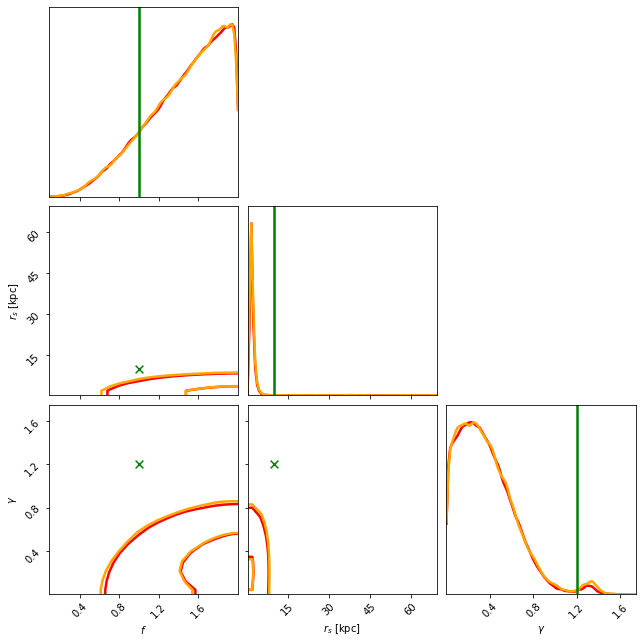

In [11]:
nBDs = 100 ; sigma = 0.2
f = 1.; gamma = 1.2; rs = 10.

filepath = ("/home/mariacst/exoplanets/running/Tcut_non_linear/onlySigmaT/results/only1/")
_file    = open(filepath + "posterior_Tcut_onlySigmaT_N100_gamma1.2rs10.0_nwalkers300_steps9000_v1", "rb") 
samples  = pickle.load(_file)

smooth=1.
fig, axes = corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
                   levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
                   plot_density=False, fill_contours=False, smooth=smooth, color="red",)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="red", lw=2.5)   
    

_file    = open(filepath + "posterior_Tcut_onlySigmaT_N100_gamma1.2rs10.0_nwalkers150_steps6000_v1", "rb") 

samples  = pickle.load(_file)

smooth=1.
corner(np.array([samples[:, 0], samples[:, 2], samples[:, 1]]).T, 
               levels=(1-np.exp(-0.5), 1-np.exp(-2)), plot_datapoints=False, 
               plot_density=False, fill_contours=False, smooth=smooth, color="orange", fig=fig)
# plot KDE smoothed version of distributions
for axidx, samps in zip([0, 4, 8], np.array([samples[:, 0], samples[:, 2], samples[:, 1]])):
    kde   = gaussian_kde(samps)
    xvals = fig.axes[axidx].get_xlim(); xvals = np.linspace(xvals[0], xvals[1], 100)
    fig.axes[axidx].plot(xvals, kde(xvals)/np.max(kde(xvals)), color="orange", lw=2.5) 
    
axes[0, 0].axvline(1., color="g", ls="-", lw=2.5); axes[1, 1].axvline(rs, color="g", ls="-", lw=2.5); 
axes[2, 2].axvline(gamma, color="g", ls="-", lw=2.5); axes[1, 0].scatter(f, rs, marker="x", color="g", s=60); 
axes[2, 0].scatter(f, gamma, marker="x", color="g", s=60); axes[2, 1].scatter(rs, gamma, marker="x", color="g", s=60);

axes[1, 0].set_ylabel(r"$r_s$ [kpc]"); axes[2, 0].set_xlabel(r"$f$"); axes[2, 0].set_ylabel(r"$\gamma$")
axes[2, 1].set_xlabel(r"$r_s$ [kpc]"); axes[2, 2].set_xlabel(r"$\gamma$")

In [3]:
nBDs = 100 ; sigma = 0.2
f = 1.; gamma = 1.2; rs = 10.

rank = 101
filepath = "/hdfs/local/mariacst/exoplanets/results/onlySigmaT/posterior/N100/"
_file    = open(filepath + ("posterior_Tcut_onlySigmaT_N%i_sigma0.1_gamma1.2rs10.0_nwalkers300_steps9000_v%i" 
                            %(nBDs, rank)), "rb") 
samples  = pickle.load(_file)

<IPython.core.display.Javascript object>


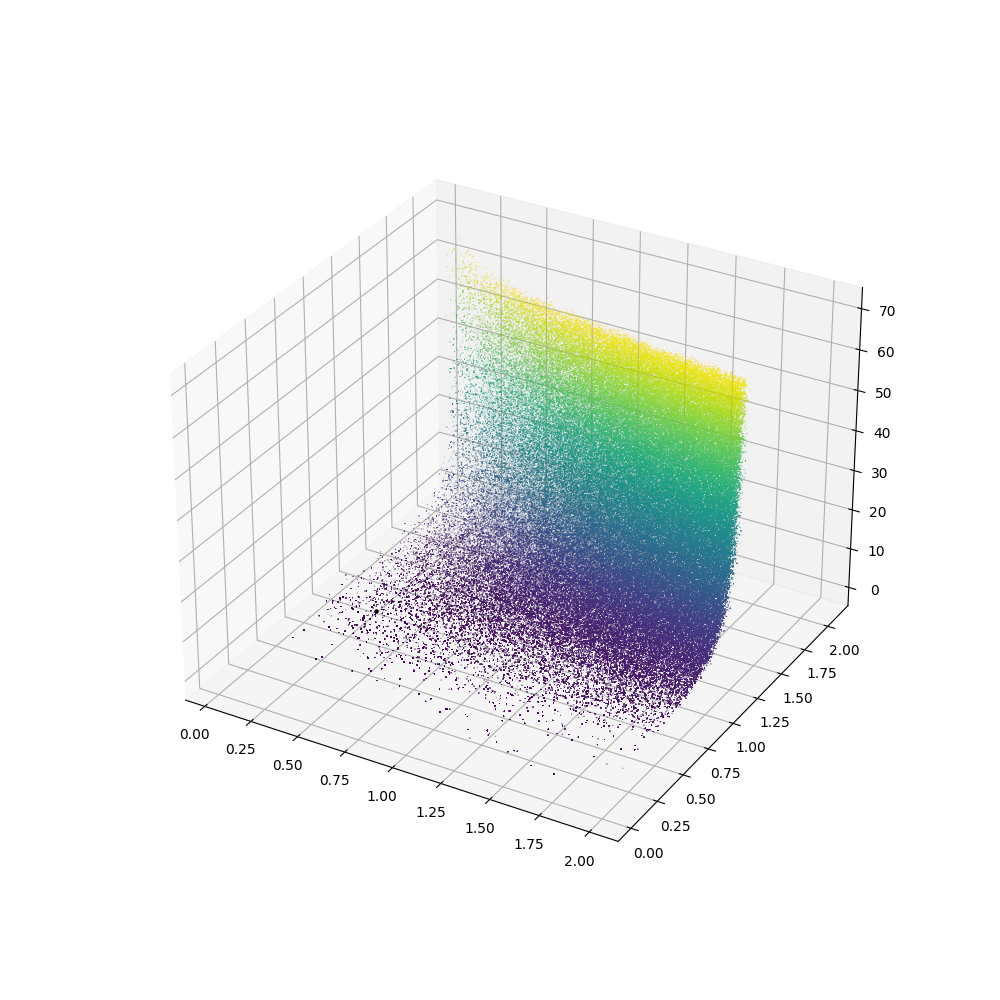

In [20]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

#plot_ = ax.scatter3D(data[1], data[2], data[0], s=0.1)
ax.scatter(samples[:, 0], samples[:, 1], samples[:, 2],  c=samples[:, 2], cmap='viridis', linewidth=0.5, s=0.001)

ax.scatter(0.3342, 0.8636, 0.3231, color="k", s=5)

plt.show()

<IPython.core.display.Javascript object>


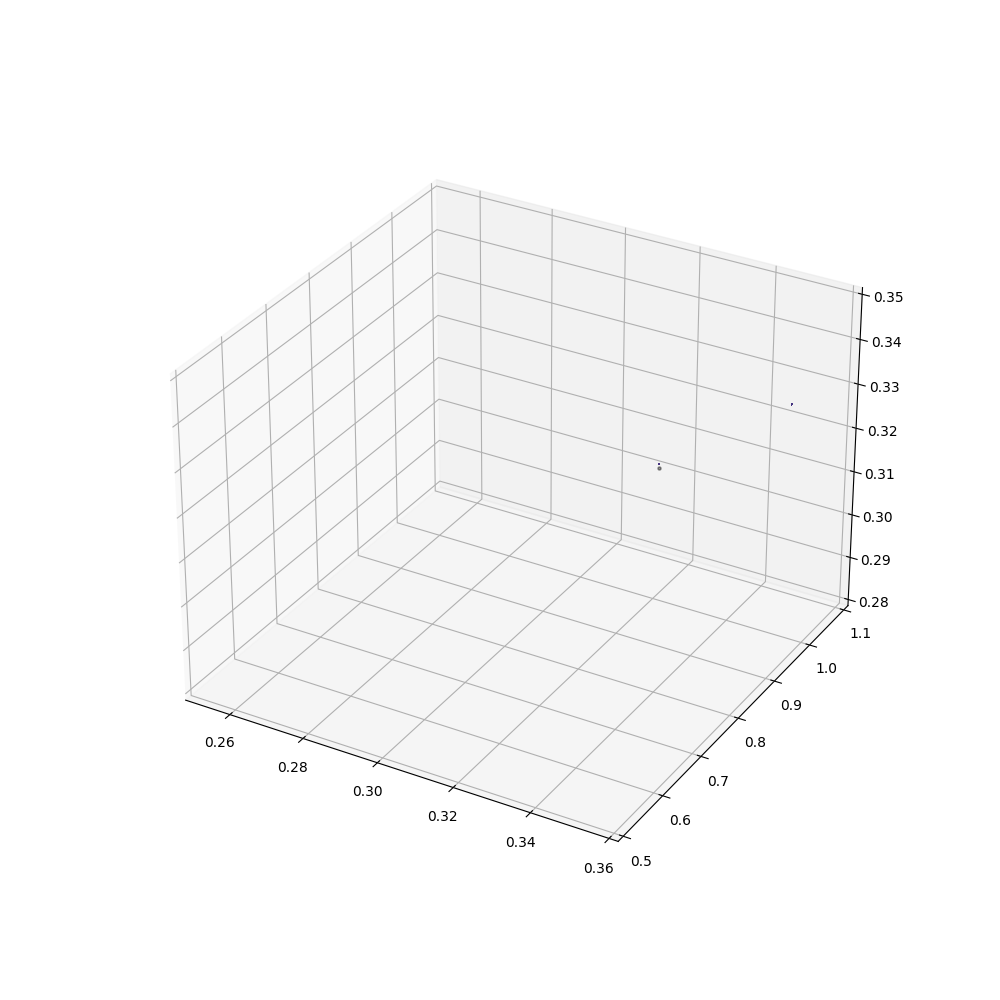

In [19]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

#plot_ = ax.scatter3D(data[1], data[2], data[0], s=0.1)
ax.scatter(samples[:, 1], samples[:, 2], samples[:, 0],  c=samples[:, 0], cmap='viridis', linewidth=0.5, s=0.1)

ax.scatter(0.3342, 0.8636, 0.3231, color="k", s=5, alpha=0.4)

ax.set_xlim(0.25, 0.36); ax.set_ylim(0.5, 1.1); ax.set_zlim(0.28, 0.35)

plt.show()

<IPython.core.display.Javascript object>


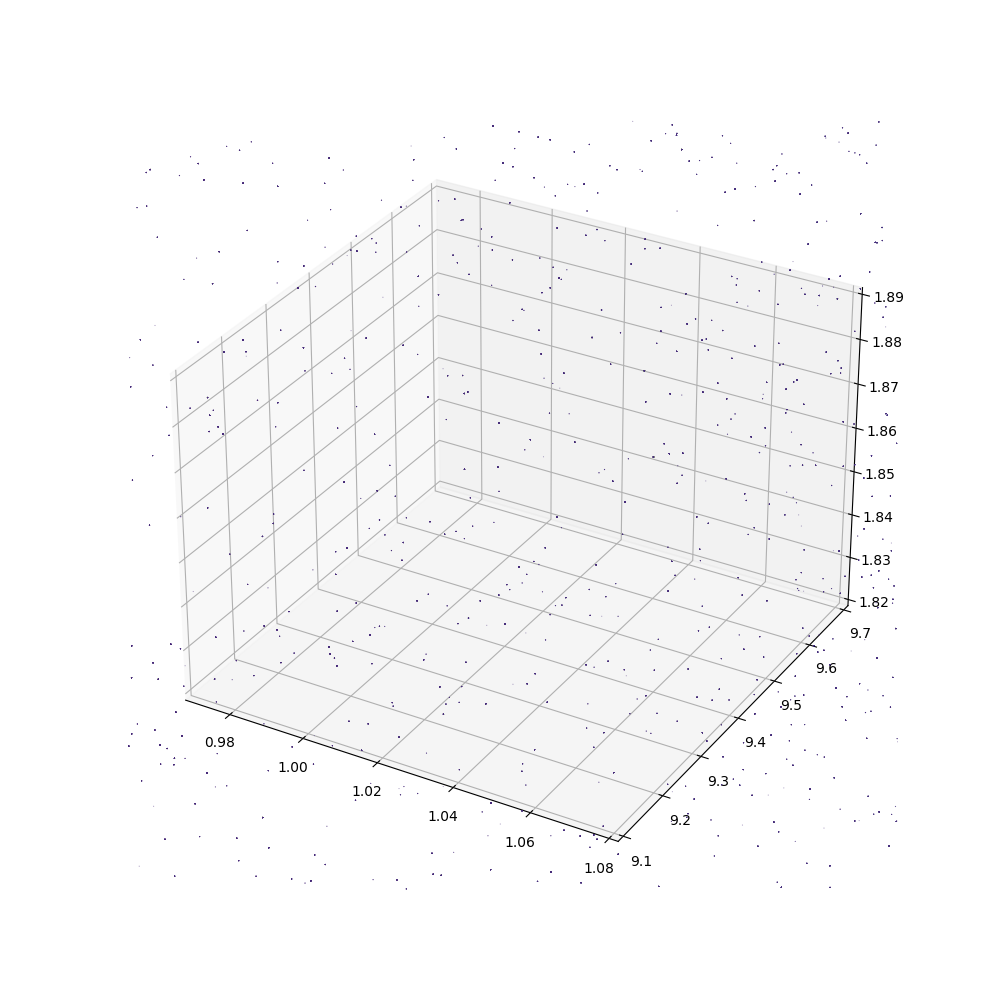

In [18]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(111, projection='3d')

#plot_ = ax.scatter3D(data[1], data[2], data[0], s=0.1)
ax.scatter(samples[:, 1], samples[:, 2], samples[:, 0],  c=samples[:, 2], cmap='viridis', linewidth=0.5, s=0.1)

ax.set_xlim(0.97, 1.08); ax.set_ylim(9.1, 9.7); ax.set_zlim(1.82, 1.89)

plt.show()